# M5A3 - Identificação de Elementos Visuais em UI de Aplicativos

Na prática de hoje vamos refinar um modelo para a tarefa de indetificação de elementos visuais.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Validar o modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [3]:
!pip install torch torchvision datasets tqdm ipywidgets

Importar as bibliotecas

In [4]:
import datasets
import torch
import torchvision
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://huggingface.co/datasets/mrtoy/mobile-ui-design

In [5]:
# Baixando dataset.
# Esse dataset possui apenas split de treino.
dataset = datasets.load_dataset("mrtoy/mobile-ui-design", split="train")

# Split dataset.
split_ds = dataset.train_test_split(test_size=0.1, seed=42)

# Pegar splits de dados.
train_dataset = split_ds["train"]
test_dataset = split_ds["test"]

# Transformações dos dados.
def transforms(examples):
    #Transformações das imagens.
    transforms = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(), # Transforma em tensor.
        torchvision.transforms.Resize((640, 480)), # Faz resize das imagens.
    ])

    images = [transforms(image) for image in examples["image"]] # Aplica nas imagens

    # Intera nos dados de bounding boxes e classes.
    targets = []
    for objs in examples["objects"]:
        len_objs = len(objs["category"])
        for i in range(len_objs):
            boxes = torch.tensor(objs["bbox"][i], dtype=torch.float32)
            boxes = torchvision.ops.box_convert(boxes, in_fmt="xywh", out_fmt="xyxy").unsqueeze(0) # Converte o formato da bbox.          

            label_map = {"rectangle": 0, "text": 1, "group": 2, "image": 3}
            labels = torch.tensor(label_map[objs["category"][i]], dtype=torch.int64).unsqueeze(0) # Transforma categoria em int.
            
            target = {"boxes": boxes, "labels": labels}
            targets.append(target)
    
    # Retorna dicionário compatível com dataloader.
    return {"image": images, "target": targets}

train_dataset =  train_dataset.with_transform(transforms)
test_dataset = test_dataset.with_transform(transforms)

def collate_fn(batch):
    # Organiza o retorno do dataloader.
    images = [item["image"] for item in batch]
    targets = [item["target"] for item in batch]
    return images, targets

# Criando dataloaders.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

## Refinar Modelo

Na prática de hoje iremos refinar o modelo **Faster R-CNN** disponível no torchvision.

In [ ]:
# Definindo dispositivo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carregando modelo.
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 5 # número de classes no nosso dataset + 1 para a classe background.
in_features = model.roi_heads.box_predictor.cls_score.in_features # número de features da última camada.
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes) # substitui a última camada do modelo.

model.to(device) # Colocando modelo no dispositivo.

# Definindo o otimizador.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

# Treinamento do modelo
model.train()
epochs = 1 # Alterar para treinar mais epocas.
for epoch in range(epochs):
    iteration = 0
    for images, targets in tqdm(train_loader):
        # Muda o dispostivo de processamento dos dados.
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Modelo retorna um dicionário de losses durante o treinamento.
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        if iteration % 100 == 0:
            print(f"Total loss: {losses.item()}")
        iteration += 1

  0%|          | 0/1766 [00:00<?, ?it/s]

Total loss: 1.7234158515930176
Total loss: 0.2000245451927185
Total loss: 0.28329986333847046
Total loss: 0.16455818712711334
Total loss: 0.209916353225708
Total loss: 0.16252194344997406
Total loss: 0.10754236578941345
Total loss: 0.08866524696350098
Total loss: 0.11319637298583984
Total loss: 0.2817140221595764
Total loss: 0.08064517378807068
Total loss: 0.0820394828915596
Total loss: 0.08151973783969879
Total loss: 0.09801098704338074
Total loss: 0.11931748688220978
Total loss: 0.22272548079490662
Total loss: 0.18795257806777954
Total loss: 0.20065033435821533


## Validar Modelo

Agora vamos testar o nosso modelo.

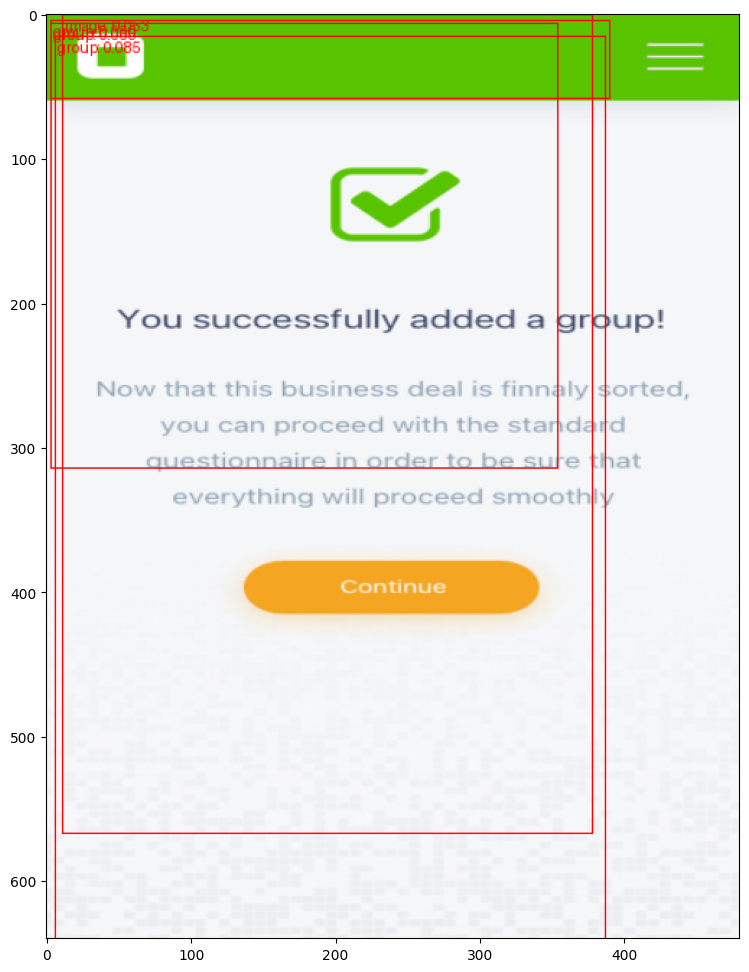

In [9]:
# Tamanho do dataset de teste.
len_test_data = len(test_dataset)

# Sortear amostra do dataset de teste.
idx = torch.randint(len_test_data, (1,))

# Modelo em modo de avaliação
model.eval()
with torch.no_grad():
    x = test_dataset[idx]["image"][0]
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


inverse_label_map = {0:"rectangle", 1:"text", 2:"group", 3:"image"}
image = x
image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"{inverse_label_map[int(label.cpu())]}: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = torchvision.utils.draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0).cpu())

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.pytorch.org/vision/master/models/faster_rcnn.html
- https://huggingface.co/datasets/mrtoy/mobile-ui-design
- https://huggingface.co/datasets
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente treinar por mais tempo, os resultados melhoram?
- [ ] Tente alterar alguns hiperparâmetros de treinamento, batch e resolução da imagens, learning rate e veja como isso altera os resultados.